# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [18]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
np.set_printoptions(precision=3, suppress=True)


In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\uciml\iris\versions\2


In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\parulpandey\palmer-archipelago-antarctica-penguin-data\versions\1


In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


In [23]:
df_iris = pd.read_csv(r"D:\L-NMPTDL&AI\NMPTDL&AI\Bài học\Clustering\Week7_24696171_HuynhGiaPhat\data\Iris.csv")

## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [24]:
def chuan_hoa_minmax(x_train, x_test):
    x_min = np.min(x_train, axis=0)
    x_max = np.max(x_train, axis=0)

    mau_so = x_max - x_min
    mau_so[mau_so == 0] = 1.0

    x_train_scaled = (x_train - x_min) / mau_so
    x_test_scaled = (x_test - x_min) / mau_so

    return x_train_scaled, x_test_scaled


def tinh_khoang_cach(test_s, x_train):
    khoang_cach = np.sqrt(
        np.sum((x_train - test_s) ** 2, axis=1)
    )

    return khoang_cach


def du_doan_1_mau(test_s, x_train, y_train, K):
    khoang_cach = tinh_khoang_cach(test_s, x_train)

    idx_gan_nhat = np.argsort(khoang_cach)[:K]

    nhan_gan_nhat = y_train[idx_gan_nhat]

    counts = np.bincount(nhan_gan_nhat)

    return np.argmax(counts)


def du_doan_tap(x_test, x_train, y_train, K):
    y_pred = np.array([
        du_doan_1_mau(test_s, x_train, y_train, K)
        for test_s in x_test
    ])

    return y_pred

In [25]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [26]:
df_iris.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [29]:
raw_iris = np.genfromtxt('data/Iris.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_iris.shape)
print(raw_iris[0])

# TODO: X_iris float (bỏ Id), Y_iris int
X_iris = df_iris.drop(columns=['Id', 'Species']).astype(float).to_numpy()
Y_iris = df_iris['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}).to_numpy()

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))


(150, 6)
['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))


K khoảng cách nhỏ nhất: [0.114 0.341 0.349 0.365 0.419]
Nhãn K láng giềng: [2 2 2 2 2]
Nhãn dự đoán: 2
Nhãn thật y_test[0]: 2
accuracy K=5, đã chuẩn hóa: 0.9666666666666667
accuracy K=5, chưa chuẩn hóa: 0.9666666666666667
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


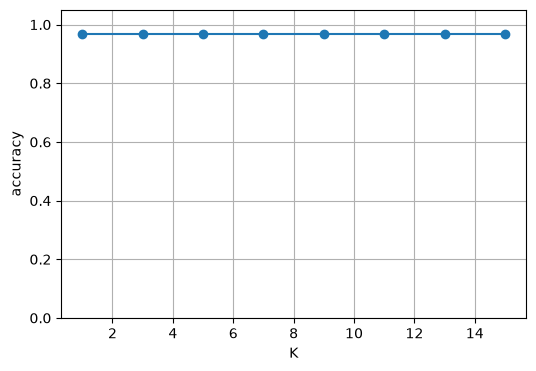

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [30]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5

# Mẫu test đầu tiên
test_s = x_test_s[0]

# Tính khoảng cách từ mẫu test đầu tiên đến toàn bộ tập train
khoang_cach = tinh_khoang_cach(test_s, x_train_s)

# Lấy K khoảng cách nhỏ nhất
idx_gan_nhat = np.argsort(khoang_cach)[:K]
khoang_cach_K = khoang_cach[idx_gan_nhat]

# Lấy nhãn của K láng giềng
nhan_K = y_train[idx_gan_nhat]

# Dự đoán nhãn
nhan_du_doan = du_doan_1_mau(test_s, x_train_s, y_train, K)

print("K khoảng cách nhỏ nhất:", khoang_cach_K)
print("Nhãn K láng giềng:", nhan_K)
print("Nhãn dự đoán:", nhan_du_doan)
print("Nhãn thật y_test[0]:", y_test[0])

print('accuracy K=5, đã chuẩn hóa:',
      accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test))

print('accuracy K=5, chưa chuẩn hóa:',
      accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)

In [31]:
X_iris.shape

(150, 4)

In [32]:
len(np.unique(Y_iris))

3

**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [33]:
# Bài 1
# 1.Số dòng 150, số cột 4, số lớp 3
# 2.Accuracy tại K=5 khi có chuẩn hóa và khi không chuẩn hóa là hoàn toàn giống nhau, nên mức chênh lệch bằng 0. Điều này cho thấy việc chuẩn hóa Min-Max trong trường hợp này không làm thay đổi kết quả phân loại của KNN.
# 3.Không đưa cột Id vào feature vì Id chỉ là mã định danh của mẫu, không mang ý nghĩa đặc trưng để phân biệt các lớp Iris. Nếu đưa Id vào, khoảng cách Euclid có thể bị ảnh hưởng bởi giá trị của Id, làm KNN tìm láng giềng dựa trên một thông tin không có ý nghĩa.


---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [34]:
df_penguins_size = pd.read_csv(r"D:\L-NMPTDL&AI\NMPTDL&AI\Bài học\Clustering\Week7_24696171_HuynhGiaPhat\data\penguins_size.csv")

In [36]:
df_penguins_size.dtypes

species                  str
island                   str
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

In [37]:
raw_pen = np.genfromtxt('data/penguins_size.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng thiếu:', raw_pen.shape)

# TODO: bỏ dòng có '' hoặc 'NA', rồi tạo X_pen (float) và Y_pen (int)
df_penguins_size = df_penguins_size.dropna()
df_penguins_size = df_penguins_size.replace(['','NA'],np.nan)
X_pen = df_penguins_size[
    ['culmen_length_mm',
     'culmen_depth_mm',
     'flipper_length_mm',
     'body_mass_g']
].astype(float).to_numpy()

Y_pen = df_penguins_size['species'].map({
    'Adelie': 0,
    'Chinstrap': 1,
    'Gentoo': 2
}).astype(int).to_numpy()
print('sau khi bỏ dòng thiếu:', X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))


trước khi bỏ dòng thiếu: (344, 7)
sau khi bỏ dòng thiếu: (334, 4) (334,)
(array([0, 1, 2]), array([146,  68, 120]))


accuracy K=5, đã chuẩn hóa: 0.9850746268656716
accuracy K=5, chưa chuẩn hóa: 0.7910447761194029
[(1, np.float64(0.985)), (3, np.float64(0.985)), (5, np.float64(0.985)), (7, np.float64(0.985)), (9, np.float64(0.985)), (11, np.float64(0.985)), (13, np.float64(0.985)), (15, np.float64(0.985))]


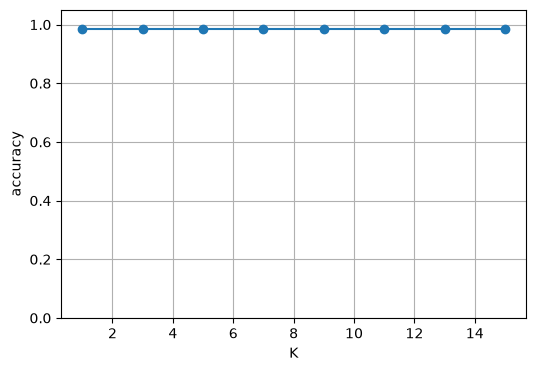

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716)])

In [38]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [41]:
# Bài 2
# 1.Bỏ 10 dòng
# 2.K=5 chưa chuẩn hóa đạt 79.10%, thấp hơn 19.40 điểm % so với 98.51% khi chuẩn hóa. body_mass_g có thang đo lớn nên dễ chi phối khoảng cách Euclid. Chuẩn hóa giúp các feature có ảnh hưởng cân bằng hơn
# 3.Tất cả các giá trị K từ 1 đến 15 đều cho Accuracy = 98.51%, nên không có K tối ưu duy nhất. Có thể chọn K = 5 để tiếp tục thực nghiệm.


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [42]:
df_heart = pd.read_csv(r"D:\L-NMPTDL&AI\NMPTDL&AI\Bài học\Clustering\Week7_24696171_HuynhGiaPhat\data\heart.csv")

In [43]:
df_heart.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [44]:
df_heart.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [48]:
raw_heart = np.genfromtxt('data/heart.csv', delimiter=',', dtype=str, skip_header=1)
print(raw_heart.shape)
print(raw_heart[0])

# TODO: X_heart float, Y_heart int
X_heart = pd.get_dummies(
    df_heart.drop(columns=['HeartDisease']),
    dtype=int
).to_numpy()

Y_heart = df_heart['HeartDisease'].to_numpy()

print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


(918, 12)
['40' 'M' 'ATA' '140' '289' '0' 'Normal' '172' 'N' '0' 'Up' '0']
(918, 20) (918,)
(array([0, 1]), array([410, 508]))


accuracy K=5: 0.8478260869565217
[(1, np.float64(0.848)), (3, np.float64(0.859)), (5, np.float64(0.848)), (7, np.float64(0.853)), (9, np.float64(0.842)), (11, np.float64(0.864)), (13, np.float64(0.864)), (15, np.float64(0.859))]


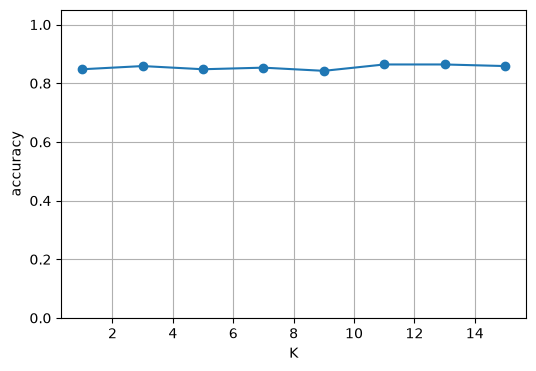

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8478260869565217),
  np.float64(0.8586956521739131),
  np.float64(0.8478260869565217),
  np.float64(0.8532608695652174),
  np.float64(0.842391304347826),
  np.float64(0.8641304347826086),
  np.float64(0.8641304347826086),
  np.float64(0.8586956521739131)])

In [49]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


In [52]:
print("Số người tập test:", len(y_test))

print("Lớp 0:", round(so_luong[0] / len(Y_heart) * 100, 2), "%")
print("Lớp 1:", round(so_luong[1] / len(Y_heart) * 100, 2), "%")

Số người tập test: 184
Lớp 0: 44.66 %
Lớp 1: 55.34 %


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [ ]:
# Bài 3
# 1.Số người tập test: 184,Lớp 0: 44.66 %,Lớp 1: 55.34 %
# 2.Có 2 K cùng đạt cao nhất: K = 11 và K = 13, Accuracy = 86.41%.
# 3.Với bài toán 2 lớp, chọn K lẻ giúp tránh trường hợp số phiếu của 2 lớp bằng nhau khi bỏ phiếu đa số, từ đó dễ xác định lớp dự đoán hơn.


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [53]:
df_mushroom = pd.read_csv(r"D:\L-NMPTDL&AI\NMPTDL&AI\Bài học\Clustering\Week7_24696171_HuynhGiaPhat\data\mushrooms.csv")

In [54]:
df_mushroom.dtypes

class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

In [56]:
raw_mush = np.genfromtxt('data/mushrooms.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng có ?:', raw_mush.shape)

# TODO: bỏ dòng chứa '?', X_mush float, Y_mush int
X_mush = pd.get_dummies(
    df_mushroom.drop(columns=['class']),
    dtype=int
).to_numpy()

Y_mush = df_mushroom['class'].map({
    'e': 0,
    'p': 1
}).to_numpy()

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


trước khi bỏ dòng có ?: (8124, 23)
(8124, 117) (8124,)
(array([0, 1]), array([4208, 3916]))


accuracy K=5: 1.0
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(1.0)), (7, np.float64(1.0)), (9, np.float64(1.0)), (11, np.float64(1.0)), (13, np.float64(1.0)), (15, np.float64(1.0))]


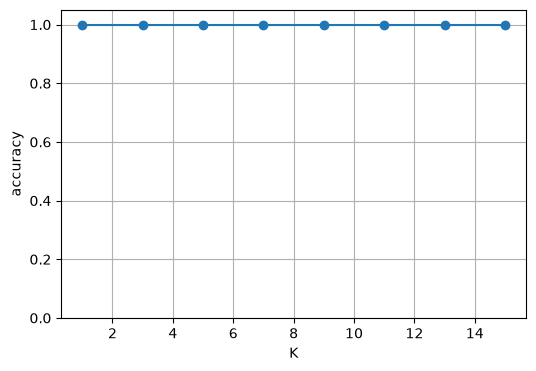

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)])

In [57]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


In [58]:
df_mushroom = df_mushroom.replace('?', np.nan).dropna()

X_mushroom = pd.get_dummies(
    df_mushroom.drop(columns=['class']),
    dtype=int
).to_numpy()

Y_mushroom = df_mushroom['class'].map({
    'e': 0,
    'p': 1
}).to_numpy()

print(X_mushroom.shape)
print(Y_mushroom.shape)

(5644, 98)
(5644,)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [ ]:
# Bài 4
# 1.Còn 5644 dòng, 98 features
# 2.Accuracy cao nhất = 1.0 (100%). Tất cả K = 1, 3, 5, 7, 9, 11, 13, 15 đều đạt Accuracy = 100%, nên không có K tối ưu duy nhất.
# 3.Giống demo tình trạng xe: đều sử dụng KNN để phân loại và dữ liệu được chuẩn hóa trước khi tính khoảng cách.
#Khác bài 1–3: Mushroom có nhiều feature sau khi mã hóa One-Hot (117 feature) và có dữ liệu thiếu ký hiệu ?, nên phải xử lý ? và mã hóa dữ liệu trước khi chuẩn hóa.
